# Cluster tracking algorithm  
1. Run cluster track  
2. Plot cluster  
3. Extract node communities

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget


from tes.ClusterTracking import SCTA
from tes.MBN_Res_Constrn import MBN_RC
from tes.data_ingestion import DataRead

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


Create object of DataRead class

In [2]:
data_read=DataRead()
mbn=MBN_RC()

D:\srg_tES\srg-tes-epilepsy-models\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Reading global order data and local order data

In [3]:
df_itr = data_read.data_read_bz2('itr20_fn.bz2')
df_loc = data_read.data_read_bz2('l20_fn.bz2')

Reset index to note iterations which have transitions

In [4]:
df_reset = df_loc.reset_index()
# reset outer index values i.e iteration numbers
itr=df_reset['level_0'].drop_duplicates()
# itr_val contains iteration numbers which had transitions
itr_val=itr.values

Iteration number which have transitions

In [5]:
itr_val

array([ 0,  2,  3,  4,  6,  9, 10, 12, 13, 14, 19], dtype=int64)

#### 1. Running SCTA for a particular iteration

In [6]:
#just put transition number (get this from itr_val) in df.loc[]

df_dum=df_loc.loc[0].T
local_order=df_dum.values


scta = SCTA(mbn.binary_conn, 
            local_order, 
            local_order_phase = None, 
            sync_thrsh=0.5)
scta.track_clusters()
scta.update_synchronization_cluster_stats()



Cluster tracking complete!


#### 2. Plot of cluster track for an iteration

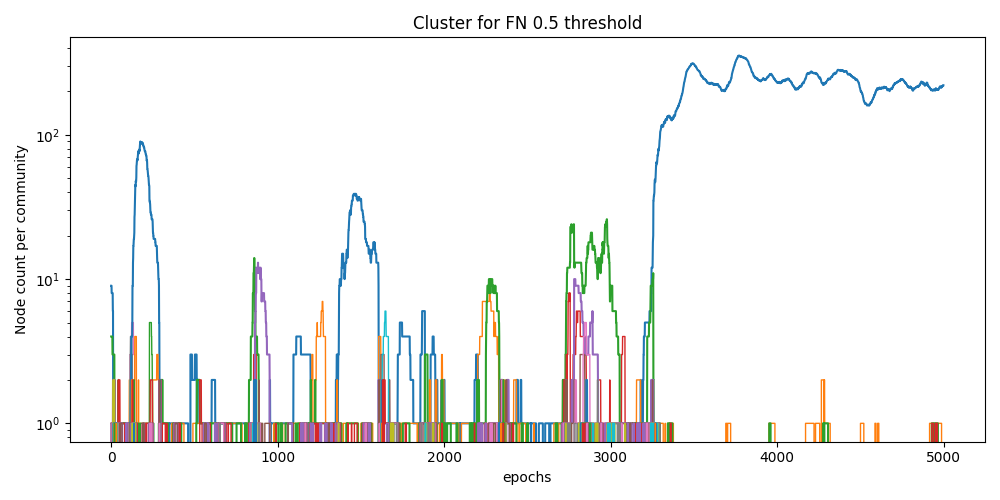

In [7]:
f1 = plt.figure(figsize=(10, 5))
for i in range(scta.MIN_CLUSTER_ID, scta.MAX_CLUSTER_ID):
    if np.max(scta.count_per_sync_cluster[:,i]) > 10:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], label=""+str(i))
    else:
        plt.plot(np.linspace(0, scta.window_size-1, scta.window_size), 
                 scta.count_per_sync_cluster[:,i], linewidth=1)

plt.xlabel("epochs")
plt.ylabel("Node count per community")
plt.yscale("log")
plt.title('Cluster for FN 0.5 threshold')
plt.tight_layout()

#### 3. Extract node communities data

In [ ]:
type(scta.node_communities)